In [2]:
!pip install tensorflow

In [3]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [8]:
!pip install tensorflow opencv-python numpy matplotlib

In [40]:
!pip install ipywidgets ipywebrtc opencv-python

   ---------------------------------------- 0.0/260.7 kB ? eta -:--:--
   -------------- ------------------------- 92.2/260.7 kB 1.8 MB/s eta 0:00:01
   ---------------------------------------- 260.7/260.7 kB 2.3 MB/s eta 0:00:00


## Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

os.chdir(r"D:\Facial_Emotion_Detection")

print("TensorFlow:", tf.__version__)
print("OpenCV:", cv2.__version__)
print("Project path:", os.getcwd())

TensorFlow: 2.21.0
OpenCV: 4.11.0
Project path: D:\Facial_Emotion_Detection


## Dataset load

In [2]:
train_data = ImageDataGenerator(rescale=1./255)
val_data = ImageDataGenerator(rescale=1./255)
test_data = ImageDataGenerator(rescale=1./255)

train = train_data.flow_from_directory(
    "data/train",
    target_size=(48, 48),
    color_mode="grayscale",
    class_mode="categorical"
)

val = val_data.flow_from_directory(
    "data/val",
    target_size=(48, 48),
    color_mode="grayscale",
    class_mode="categorical"
)

test = test_data.flow_from_directory(
    "data/test",
    target_size=(48, 48),
    color_mode="grayscale",
    class_mode="categorical",
    shuffle=False
)

print("Classes:", train.class_indices)

Found 28709 images belonging to 7 classes.
Found 3589 images belonging to 7 classes.
Found 3589 images belonging to 7 classes.
Classes: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6}


## Emotion names

In [3]:
emotions = [
    "Angry",
    "Disgust",
    "Fear",
    "Happy",
    "Sad",
    "Surprise",
    "Neutral"
]

print(emotions)

['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']


## Sample images

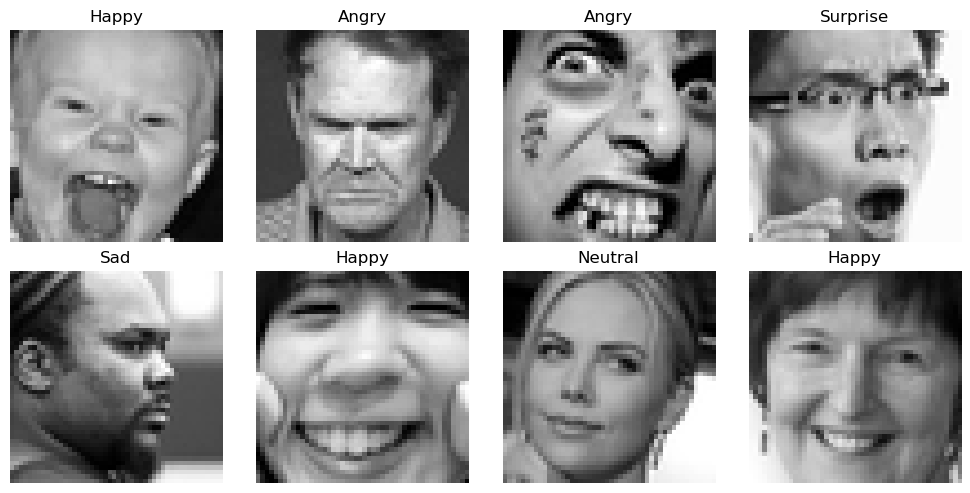

In [4]:
images, labels = next(train)

plt.figure(figsize=(10, 5))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(emotions[np.argmax(labels[i])])
    plt.axis("off")

plt.tight_layout()
plt.show()

## CNN Model

In [5]:
model = Sequential([
    tf.keras.Input(shape=(48, 48, 1)),

    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation="relu"),
    Dense(7, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 46, 46, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 23, 23, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 21, 21, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 10, 10, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6400)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         819,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 7)                   │             903 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 839,047 (3.20 MB)

 Trainable params: 839,047 (3.20 MB)

 Non-trainable params: 0 (0.00 B)

## Compile

In [6]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

## Training

In [7]:
history = model.fit(
    train,
    validation_data=val,
    epochs=10
)

Epoch 1/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 1993s 2s/step - accuracy: 0.3956 - loss: 1.5584 - val_accuracy: 0.4656 - val_loss: 1.4021
Epoch 2/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 537s 594ms/step - accuracy: 0.4903 - loss: 1.3370 - val_accuracy: 0.4982 - val_loss: 1.3159
Epoch 3/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 72s 80ms/step - accuracy: 0.5402 - loss: 1.2153 - val_accuracy: 0.5118 - val_loss: 1.2772
Epoch 4/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 72s 80ms/step - accuracy: 0.5861 - loss: 1.1043 - val_accuracy: 0.5313 - val_loss: 1.2451
Epoch 5/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 127s 141ms/step - accuracy: 0.6306 - loss: 0.9947 - val_accuracy: 0.5400 - val_loss: 1.2481
Epoch 6/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 379s 405ms/step - accuracy: 0.6795 - loss: 0.8743 - val_accuracy: 0.5302 - val_loss: 1.3041
Epoch 7/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 95s 105ms/step - accuracy: 0.7269 - loss: 0.7516 - val_accuracy: 0.5500 - val_loss: 1.3493
Epoch 8/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 75s 84ms/step - accuracy: 0.7774 - loss: 0.

## Save model

In [9]:
model.save("emotion_model.keras")

print("Model Save Successfully!")

Model Save Successfully!


## Accuracy & Loss Graph

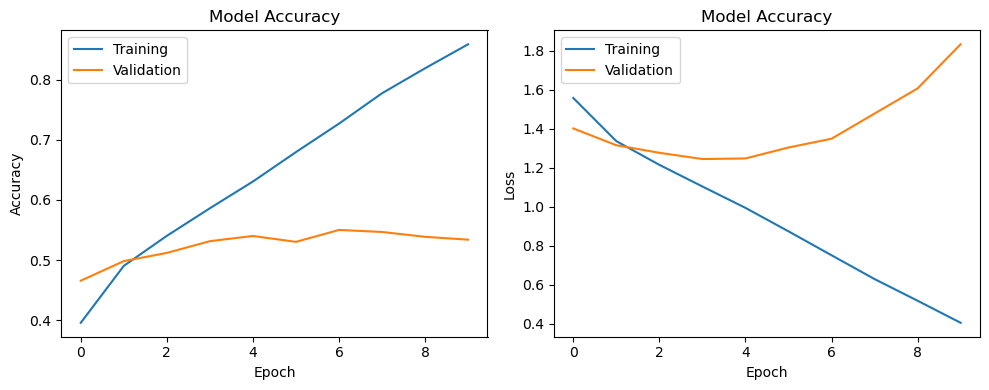

In [10]:
plt. figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label ="Training")
plt.plot(history.history["val_accuracy"], label ="Validation")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label ="Training")
plt.plot(history.history["val_loss"], label ="Validation")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## Test Accuracy

In [11]:
test_loss, test_accuracy = model.evaluate(test)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

113/113 ━━━━━━━━━━━━━━━━━━━━ 63s 564ms/step - accuracy: 0.5472 - loss: 1.7339
Test Accuracy: 0.5472276210784912
Test Loss: 1.7339168787002563


## Prediction on one test image

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


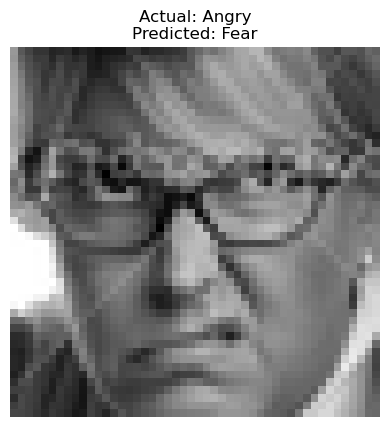

In [12]:
images, labels = next(test)

prediction = model.predict(images)

index = 0

actual = emotions[np.argmax(labels[index])]
predicted = emotions[np.argmax(prediction[index])]

plt.imshow(images[index].squeeze(), cmap="gray")
plt.title(f"Actual: {actual}\nPredicted: {predicted}")
plt.axis("off")
plt.show()

# Live Expression

In [13]:
import os
os.chdir(r"D:\Facial_Emotion_Detection")
print(os.getcwd())

D:\Facial_Emotion_Detection


In [14]:
!python live_emotion.py

I0000 00:00:1790170700.530991   20632 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790170722.901075   20632 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
